In [1]:
import numpy as np
import matplotlib.pyplot as plt 

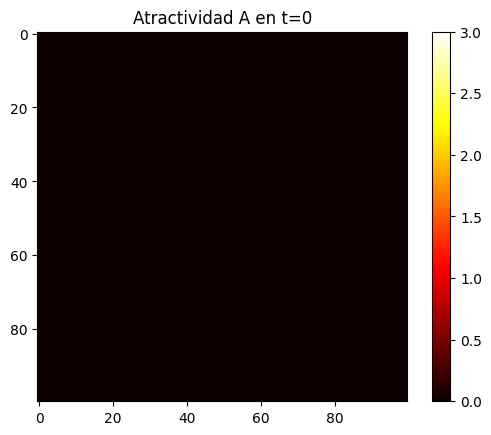

0.033333333333333326


In [2]:
N = 100

# Inicamos las matrices Ao del atractivo estático de cada celda y B como el atractivo dinámico

Ao = np.ones((N,N)) * (1/30)

B = np.zeros((N,N))

# El atractivo total de cada celda:

A = Ao + B

n = np.random.randint(0, 10, size=(N,N))  # número de criminales en cada celda

plt.imshow(A, cmap='hot',vmin=0, vmax=3)
plt.colorbar()
plt.title(f'Atractividad A en t={0}')
plt.show()

print(np.mean(A))

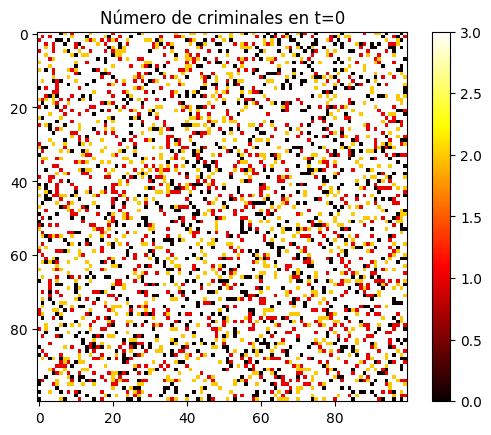

In [3]:
plt.imshow(n, cmap='hot',vmin=0, vmax=3)
plt.colorbar()
plt.title(f'Número de criminales en t={0}')
plt.show()

In [4]:

# Parámetros del modelo
omega = 1/15 # tasa de decaimiento de B
eta = 0.5   # peso de difusión a vecinos
gamma = 1   # tasa de generación de nuevos criminales


omega = 1/15
theta = 5.6
eta = 0.03
gamma = 0.002



In [5]:
# Actualiza B

def update_B_vN(B, n, omega, eta, theta):
    # Vecindad de von Neumann (4 vecinos)

    z = 4

    # Defines la suma del atractivo dinámico de los vecinos (efecto ventana rota)

    neighbors = (np.roll(B, 1, axis=0) + np.roll(B, -1, axis=0) +
                 np.roll(B, 1, axis=1) + np.roll(B, -1, axis=1))
    
    E = n  # crímenes ocurridos (por ahora aproximamos con n)
    
    B_new = ((1 - eta) * B + (eta / z) * neighbors) * (1 - omega) + theta*E
    return B_new

In [6]:
def update_B_Moore(B, n, omega, eta, theta):
    z = 8  # 8 vecinos en Moore
    neighbors = (np.roll(B, 1, axis=0) + np.roll(B, -1, axis=0) +
                 np.roll(B, 1, axis=1) + np.roll(B, -1, axis=1) +
                 np.roll(np.roll(B, 1, axis=0), 1, axis=1) +   # diagonal superior izquierda
                 np.roll(np.roll(B, 1, axis=0), -1, axis=1) +  # diagonal superior derecha
                 np.roll(np.roll(B, -1, axis=0), 1, axis=1) +  # diagonal inferior izquierda
                 np.roll(np.roll(B, -1, axis=0), -1, axis=1))  # diagonal inferior derecha
    
    E = n
    B_new = ((1 - eta) * B + (eta / z) * neighbors) * (1 - omega) + theta*E
    return B_new

In [7]:
B = update_B_vN(B, n, omega, eta, theta)
print(B.round(2))

[[22.4 50.4 16.8 ... 44.8  0.  39.2]
 [16.8  5.6 28.  ...  0.  22.4  5.6]
 [ 5.6 22.4 50.4 ... 11.2  0.  44.8]
 ...
 [ 0.  44.8 28.  ... 33.6 11.2 39.2]
 [39.2 44.8 28.  ... 22.4  5.6  5.6]
 [ 0.  22.4 33.6 ... 22.4  0.  44.8]]


In [8]:
def update_A(A0, B):
    return A0 + B

In [9]:
def update_criminals_vN(n, A, gamma):
    n_new = np.zeros((N, N), dtype=int)
    E = np.zeros((N, N), dtype=int)  # crímenes ocurridos
    
    for i in range(N):
        for j in range(N):
            for _ in range(n[i, j]):
                p = 1 - np.exp(-A[i, j])
                if np.random.random() < p:
                    # Comete crimen y desaparece
                    E[i, j] += 1
                else:
                    # Se mueve a un vecino sesgado por atractividad
                    neighbors = [(i-1)%N, (i+1)%N, (i)%N, (i)%N]
                    neighbors_j = [(j)%N, (j)%N, (j-1)%N, (j+1)%N]
                    weights = [A[ni, nj] for ni, nj in zip(neighbors, neighbors_j)]
                    weights = np.array(weights) / sum(weights)
                    idx = np.random.choice(4, p=weights)
                    n_new[neighbors[idx], neighbors_j[idx]] += 1
    
    # Generar nuevos criminales a tasa gamma
    new_criminals = np.random.poisson(gamma, size=(N, N))
    n_new += new_criminals
    
    return n_new, E

In [10]:
def update_criminals_Moore(n, A, gamma):
    n_new = np.zeros((N, N), dtype=int)
    E = np.zeros((N, N), dtype=int)
    
    for i in range(N):
        for j in range(N):
            for _ in range(n[i, j]):
                p = 1 - np.exp(-A[i, j])
                if np.random.random() < p:
                    E[i, j] += 1
                else:
                    # 8 vecinos de Moore
                    neighbors_i = [(i-1)%N, (i+1)%N, i,        i,
                                   (i-1)%N, (i-1)%N, (i+1)%N, (i+1)%N]
                    neighbors_j = [j,        j,       (j-1)%N, (j+1)%N,
                                   (j-1)%N, (j+1)%N, (j-1)%N, (j+1)%N]
                    weights = [A[ni, nj] for ni, nj in zip(neighbors_i, neighbors_j)]
                    weights = np.array(weights) / sum(weights)
                    idx = np.random.choice(8, p=weights)
                    n_new[neighbors_i[idx], neighbors_j[idx]] += 1
    
    new_criminals = np.random.poisson(gamma, size=(N, N))
    n_new += new_criminals
    
    return n_new, E

In [11]:
print(A.round(2))

[[0.03 0.03 0.03 ... 0.03 0.03 0.03]
 [0.03 0.03 0.03 ... 0.03 0.03 0.03]
 [0.03 0.03 0.03 ... 0.03 0.03 0.03]
 ...
 [0.03 0.03 0.03 ... 0.03 0.03 0.03]
 [0.03 0.03 0.03 ... 0.03 0.03 0.03]
 [0.03 0.03 0.03 ... 0.03 0.03 0.03]]


In [12]:
T = 10000  # número de pasos

for t in range(T):
    # 1. Mover criminales y registrar crímenes
    #n, E = update_criminals_vN(n, A, gamma)
    n, E = update_criminals_Moore(n, A, gamma)

    # 2. Actualizar B con los crímenes ocurridos
    #B = update_B_vN(B, E, omega, eta)
    B = update_B_Moore(B, E, omega, eta, theta)

    # 3. Actualizar A
    A = update_A(Ao, B)

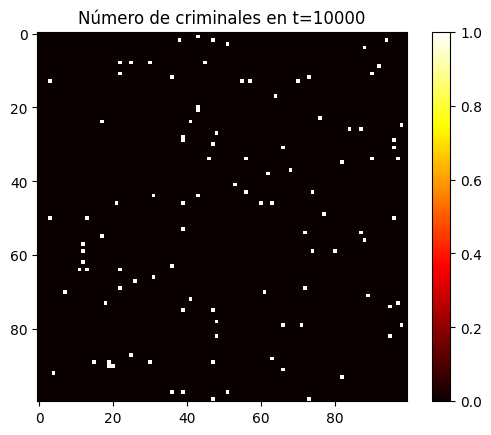

In [13]:
plt.imshow(n, cmap='hot',vmin=n.min(), vmax=n.max())
plt.colorbar()
plt.title(f'Número de criminales en t={T}')
plt.show()

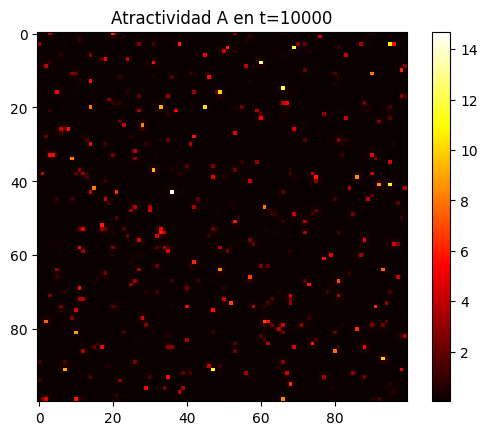

In [14]:
plt.imshow(A, cmap='hot',vmin=A.min(), vmax=A.max())
plt.colorbar()
plt.title(f'Atractividad A en t={T}')
plt.show()

In [ ]:
import matplotlib.animation as animation

# Reinicializar
Ao_gif = np.ones((N, N)) * (1/30)
B = np.zeros((N, N))
A = Ao_gif + B
n = np.random.randint(0, 3, size=(N, N))

# Guardar frames
frames = []
fig, ax = plt.subplots()
im = ax.imshow(A, cmap='hot', vmin=0, vmax=3, animated=True)
plt.colorbar(im)

for t in range(10000):
    n, E = update_criminals_Moore(n, A, gamma)
    B = update_B_Moore(B, E, omega, eta, theta)
    A = update_A(Ao_gif, B)
    
    if t % 5 == 0:  # guarda un frame cada 5 pasos
        im = ax.imshow(A, cmap='hot', vmin=0, vmax=3, animated=True)
        title = ax.text(0.5, 1.01, f't={t}', ha='center', va='bottom',
                        transform=ax.transAxes, fontsize=12, animated=True)
        frames.append([im, title])

ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)
ani.save('hotspots.gif', writer='pillow')
plt.close()
print("GIF guardado")